# Week 2: Introduction to Vision and the Digital Image

This notebook includes all exercises from this session. The setup, image loading, and visualization code is provided so that you can focus on the small implementation tasks. Please run the provided cells in order before running your own code.

This first tutorial is intentionally short. It introduces Jupyter and applies the lecture concepts to a real image.

Complete the cells marked **TODO**.


## Useful information for this tutorial

A notebook contains Markdown cells and Python code cells. Run a cell with `Shift + Enter`. Run the cells in order because later cells use variables defined earlier.

Images are represented as NumPy arrays:

- an RGB image has shape `(height, width, 3)`,
- a grayscale image has shape `(height, width)`,
- this notebook stores intensity values in `[0, 1]`,
- pixels are indexed as `image[y, x, channel]`.

Run the next cell once, change the message, and run it again.


In [1]:
message = "Hello, Visual Computing!"
print(message)

Hello, Visual Computing!


## Setup

The following cell loads the supplied photograph and defines the visualization helpers used throughout the exercise.


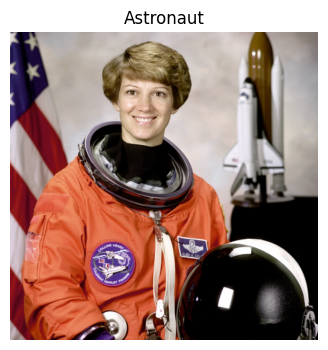

shape: (512, 512, 3)
dtype: float64
value range: 0.0 to 1.0


In [2]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.cmap"] = "gray"


def show_image(img, title="", cmap=None, vmin=None, vmax=None):
    '''Display a grayscale or RGB image stored as a NumPy array.'''
    plt.figure(figsize=(5, 4))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray", vmin=vmin, vmax=vmax)
    else:
        plt.imshow(np.clip(img, 0, 1))
    plt.title(title)
    plt.axis("off")
    plt.show()
    plt.close()


def show_images(images, titles, columns=3, vmin=None, vmax=None):
    '''Display several images in a compact comparison grid.'''
    rows = int(np.ceil(len(images) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3 * rows), squeeze=False)

    for axis, img, title in zip(axes.flat, images, titles):
        if img.ndim == 2:
            axis.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
        else:
            axis.imshow(np.clip(img, 0, 1))
        axis.set_title(title)
        axis.axis("off")

    for axis in axes.flat[len(images):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


image_path = Path("astronaut.png")
if not image_path.exists():
    image_url = "https://raw.githubusercontent.com/tavisualcomputing/viscomp2026/main/Exercises/W2/astronaut.png"
    urlretrieve(image_url, image_path)

image = plt.imread(image_path)
if image.ndim == 3 and image.shape[2] == 4:
    image = image[:, :, :3]
image = image.astype(float)
if image.max() > 1:
    image /= 255.0

show_image(image, "Astronaut")
print("shape:", image.shape)
print("dtype:", image.dtype)
print("value range:", image.min(), "to", image.max())


## EXERCISE 1.A - Image shape and pixel indexing

Read the height, width, and number of channels from `image.shape`. Then read the RGB value at row 100, column 220. Row and column indices are 0-based.


In [3]:
# read height, width, and channels from image.shape.

print("height: ", image.shape[0])
print("width: ", image.shape[1])

# read the RGB value at row 100, column 220 (0-based).

print("rgb value at (100, 220): ", image[99, 2])


height:  512
width:  512
rgb value at (100, 220):  [0.86274511 0.74509805 0.64705884]


## EXERCISE 1.B - RGB to grayscale

Extract the three color channels and convert the photograph to grayscale using

`gray = 0.299 R + 0.587 G + 0.114 B`.


In [4]:
# TODO: extract the red, green, and blue channels.

@np.vectorize
def red(x):
  return x[0];

result = red(image)

# TODO: compute the weighted grayscale image.

# TODO: display the result and print its shape.


IndexError: invalid index to scalar variable.

## EXERCISE 1.C - Cropping

Using 0-based indexing, create a crop containing row indices 50 through 249 and column indices 130 through 329, inclusive. The expected shape is `(200, 200, 3)`.


In [ ]:
# TODO: create the requested crop using NumPy slicing.

# TODO: display the crop and print its shape.


## EXERCISE 2 - Downsampling

Implement nearest-neighbor downsampling by keeping every `factor`-th row and column. For this image, a factor of 4 should produce shape `(128, 128, 3)`.


In [ ]:
def downsample_nearest(img, factor):
    # TODO: return every factor-th row and every factor-th column.
    raise NotImplementedError("Complete downsample_nearest")


factors = [2, 4, 8, 16]
small_images = [downsample_nearest(image, factor) for factor in factors]
show_images(small_images, [f"Factor {factor}" for factor in factors], columns=2)

for factor, small in zip(factors, small_images):
    print(f"factor {factor}: {small.shape}")


**Display note:** Matplotlib scales each array to fill its subplot, so the four panels have the same on-screen size. The printed shapes show the actual image resolutions. At lower resolution, each stored pixel covers a larger displayed area, which makes the image look more pixelated.


### Aliasing demonstration - provided code

The sinusoidal grating has a period of 12 pixels. Downsampling keeps only every `factor`-th column. To sample this frequency above the Nyquist rate, the spacing must be smaller than 6 pixels.

- Factors 2 and 4 remain above the Nyquist rate.
- Factor 6 is exactly on the Nyquist boundary and is sensitive to sampling phase.
- Factor 8 produces a false lower-frequency pattern.
- Factor 12 always samples the same phase and produces a constant image.

These outputs illustrate aliasing: after undersampling, the samples can suggest a different signal from the original one.


In [ ]:
def make_sinusoidal_grating(height=120, width=360, period=12):
    x = np.arange(width)
    row = 0.5 + 0.5 * np.cos(2 * np.pi * x / period)
    return np.tile(row, (height, 1))


grating = make_sinusoidal_grating(period=12)
factors = [2, 4, 6, 8, 12]
grating_images = [grating] + [downsample_nearest(grating, factor) for factor in factors]
grating_titles = ["Original (period 12 px)"] + [f"Sample every {factor} px" for factor in factors]
show_images(grating_images, grating_titles, columns=3, vmin=0, vmax=1)


## EXERCISE 3 - Quantization

Implement uniform quantization. With `b` bits, one channel can represent `2**b` levels. For values in `[0, 1]`, use

`round(image * (levels - 1)) / (levels - 1)`.


In [ ]:
def quantize(img, bits):
    levels = 2 ** bits
    # TODO: implement the formula given above.
    raise NotImplementedError("Complete quantize")


bit_depths = [8, 4, 2, 1]
quantized = [quantize(gray, bits) for bits in bit_depths]
show_images(quantized, [f"{bits}-bit" for bits in bit_depths], columns=2, vmin=0, vmax=1)

for bits, img in zip(bit_depths, quantized):
    print(f"{bits}-bit: {len(np.unique(img))} values used")


## EXERCISE 4 - Image noise

Gaussian noise perturbs most pixels by a random amount. Salt-and-pepper noise replaces a sparse set of pixels with black or white.

The provided `seed` creates a reproducible random-number generator, so rerunning a function with the same seed gives the same result. Two useful methods are:

- `rng.normal(loc=0.0, scale=sigma, size=img.shape)` for Gaussian noise,
- `rng.random(size=img.shape[:2])` for one uniform random value per pixel.

Implement both functions. Use `np.clip` to keep Gaussian-noise results in `[0, 1]`. For salt-and-pepper noise, `probability` is the total probability that a pixel is corrupted: half of it is assigned to salt and half to pepper.


In [ ]:
def add_gaussian_noise(img, sigma=0.08, seed=0):
    rng = np.random.default_rng(seed)
    # TODO: use rng.normal to sample additive noise with shape img.shape.
    # TODO: add the noise to img and clip the result to [0, 1].
    raise NotImplementedError("Complete add_gaussian_noise")


def add_salt_and_pepper(img, probability=0.04, seed=1):
    rng = np.random.default_rng(seed)
    noisy = img.copy()
    random_values = rng.random(img.shape[:2])
    # TODO: salt is random_values < probability / 2.
    # TODO: pepper is probability / 2 <= random_values < probability.
    # TODO: set salt pixels to 1 and pepper pixels to 0, then return noisy.
    raise NotImplementedError("Complete add_salt_and_pepper")


### Checking the noise functions

Run the following cell after completing both functions. The observed fraction of changed salt-and-pepper pixels may be slightly below `probability` when a corrupted pixel already has the replacement value 0 or 1.


In [ ]:
sigma = 0.08
probability = 0.04

gaussian = add_gaussian_noise(image, sigma=sigma)
salt_pepper = add_salt_and_pepper(image, probability=probability)

show_images(
    [image, gaussian, salt_pepper],
    ["Clean", f"Gaussian, sigma={sigma}", f"Salt-and-pepper, p={probability}"],
    columns=3,
)

gaussian_changed = np.mean(np.any(np.abs(gaussian - image) > 1e-12, axis=2))
salt_pepper_changed = np.mean(np.any(np.abs(salt_pepper - image) > 1e-12, axis=2))
print("fraction of changed pixels, Gaussian:", gaussian_changed)
print("fraction of changed pixels, salt-and-pepper:", salt_pepper_changed)


## SAMPLE EXAM QUESTIONS

1. A continuous signal has maximum frequency `f_max` and is sampled at frequency `f_s`. State the condition required to avoid aliasing and name the artifact that appears when the condition is violated.

2. An uncompressed RGB image has resolution `1920 x 1080` and uses 8 bits per channel. How many bytes are required? If both image dimensions are divided by 2 and the image is stored as grayscale, by what factor is the required memory reduced?


## Credits

The photograph is the `astronaut` image from the scikit-image sample data collection.
